## Model Training & Evaluation

Trains an XGBoost regression model to forecast hourly household energy consumption.

**Input:** data/processed/feature_matrix.csv (8,231 rows, 47 columns)  
**Output:** models/xgb_model.pkl, models/feature_columns.json, models/model_metadata.json

**Final result:**
- Baseline MAPE (naive lag_24h): 52.71%
- Final model MAPE (>0.1 kW): 30.11%
- Final model MAPE (>0.3 kW): 24.60%
- Median absolute error: 0.13 kW
- 71.3% of predictions within 30% of actual value

**Train period:** 2016-01-08 to 2016-10-08 (80%)  
**Test period:** 2016-10-08 to 2016-12-15 (20%)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import joblib
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.float_format', '{:.4f}'.format)

# Load feature matrix and feature column list
df = pd.read_csv('../data/processed/feature_matrix.csv', 
                 index_col='time', parse_dates=True)

with open('../models/feature_columns.json', 'r') as f:
    FEATURE_COLS = json.load(f)

TARGET = 'use [kW]'

print(f"Shape: {df.shape}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Shape: (8231, 47)
Features: 31
Date range: 2016-01-08 00:00:00 to 2016-12-15 22:00:00


### Temporal Train/Test Split
Strict chronological 80/20 split. Never shuffle time series data — 
shuffling leaks future information into training and produces 
artificially good metrics that fail in production.

In [2]:
# Temporal split — 80% train, 20% test, strictly chronological
split_idx = int(len(df) * 0.80)
split_date = df.index[split_idx]

train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

X_train = train[FEATURE_COLS]
y_train = train[TARGET]
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET]

print(f"Split date: {split_date}")
print(f"\nTraining set: {train.index.min()} to {train.index.max()}")
print(f"  Rows: {len(train)}")
print(f"\nTest set: {test.index.min()} to {test.index.max()}")
print(f"  Rows: {len(test)}")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Split date: 2016-10-08 08:00:00

Training set: 2016-01-08 00:00:00 to 2016-10-08 07:00:00
  Rows: 6584

Test set: 2016-10-08 08:00:00 to 2016-12-15 22:00:00
  Rows: 1647

X_train shape: (6584, 31)
X_test shape:  (1647, 31)


In [3]:
# Baseline: predict lag_24h as the forecast (same hour yesterday)
baseline_preds = X_test['lag_24h']

def mape(actual, predicted):
    """Mean Absolute Percentage Error — measures error as % of actual value"""
    actual, predicted = np.array(actual), np.array(predicted)
    # Avoid division by zero for near-zero consumption values
    mask = actual > 0.1
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

baseline_mae  = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_mape = mape(y_test, baseline_preds)

print("=== BASELINE MODEL (naive lag_24h) ===")
print(f"MAE:  {baseline_mae:.4f} kW")
print(f"RMSE: {baseline_rmse:.4f} kW")
print(f"MAPE: {baseline_mape:.2f}%")
print(f"\nThis is the bar our XGBoost model must beat.")

=== BASELINE MODEL (naive lag_24h) ===
MAE:  0.3583 kW
RMSE: 0.5551 kW
MAPE: 52.71%

This is the bar our XGBoost model must beat.


In [4]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1       # use all CPU cores
)

print("Training XGBoost model...")
model.fit(X_train, y_train)
print("Training complete.")

# Evaluate on test set
preds = model.predict(X_test)

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape_score = mape(y_test, preds)

print(f"\n=== XGBOOST MODEL (first run) ===")
print(f"MAE:  {mae:.4f} kW")
print(f"RMSE: {rmse:.4f} kW")
print(f"MAPE: {mape_score:.2f}%")
print(f"\nBaseline MAPE was: 52.71%")
print(f"Improvement: {52.71 - mape_score:.2f} percentage points")

Training XGBoost model...
Training complete.

=== XGBOOST MODEL (first run) ===
MAE:  0.2116 kW
RMSE: 0.3209 kW
MAPE: 30.35%

Baseline MAPE was: 52.71%
Improvement: 22.36 percentage points


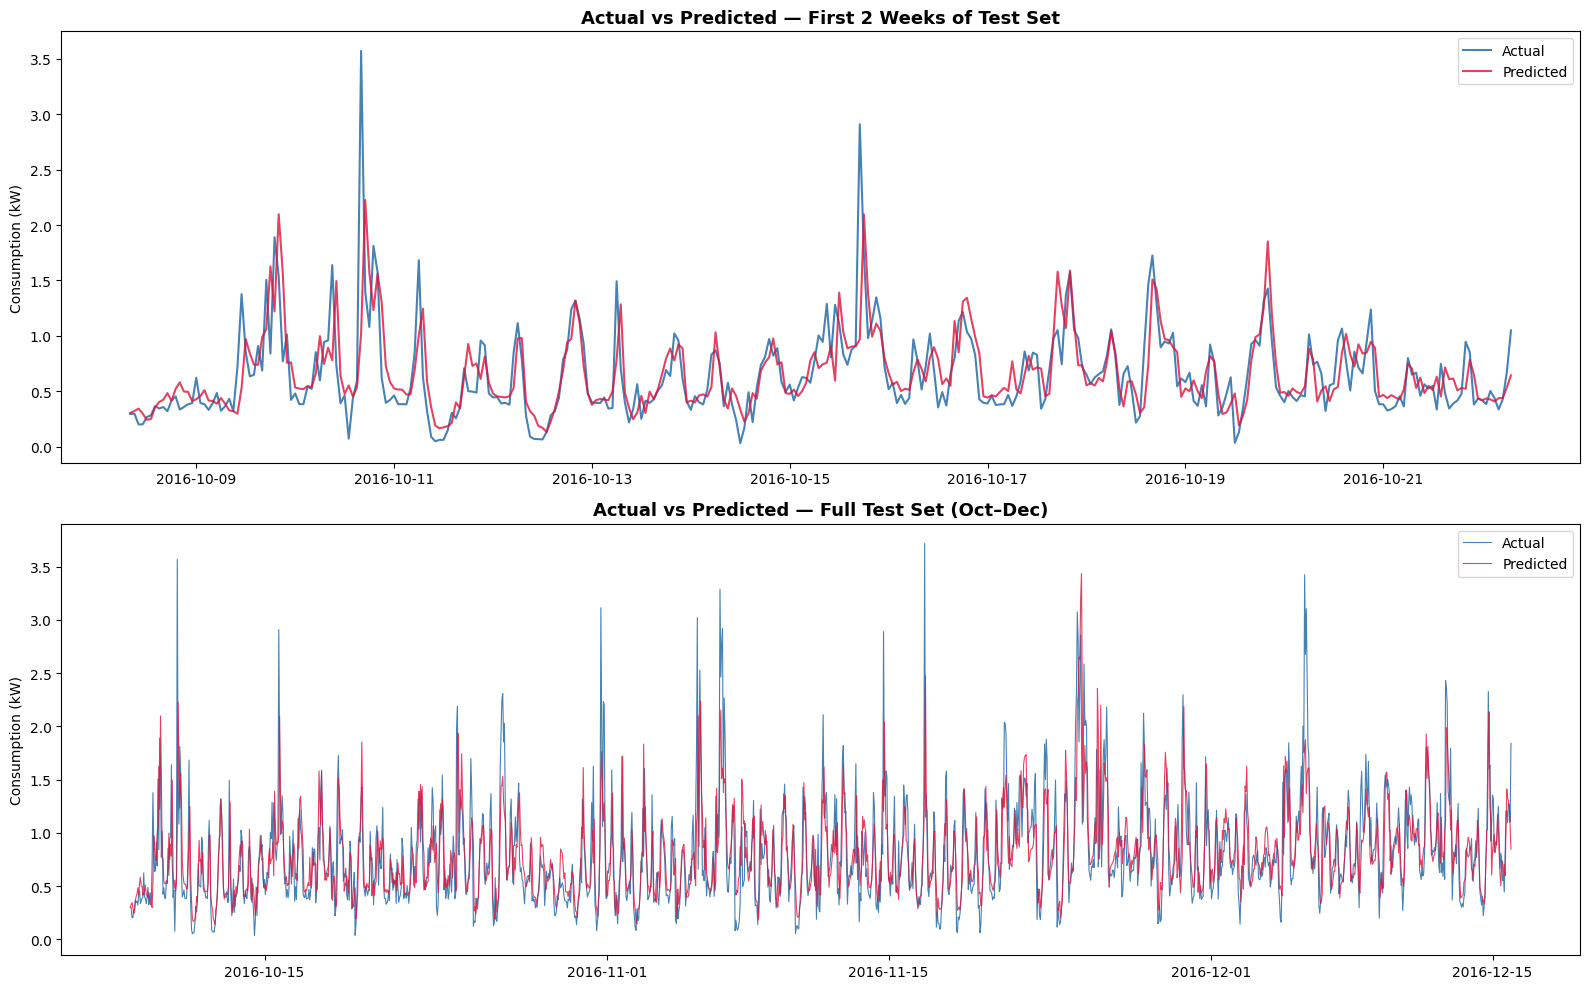

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: First 2 weeks of test set (detailed view)
plot_end = 336  # 2 weeks of hours
axes[0].plot(y_test.index[:plot_end], y_test.values[:plot_end],
             label='Actual', color='steelblue', linewidth=1.5)
axes[0].plot(y_test.index[:plot_end], preds[:plot_end],
             label='Predicted', color='crimson', linewidth=1.5, alpha=0.8)
axes[0].set_title('Actual vs Predicted — First 2 Weeks of Test Set',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Consumption (kW)')
axes[0].legend()

# Plot 2: Full test set
axes[1].plot(y_test.index, y_test.values,
             label='Actual', color='steelblue', linewidth=0.8)
axes[1].plot(y_test.index, preds,
             label='Predicted', color='crimson', linewidth=0.8, alpha=0.8)
axes[1].set_title('Actual vs Predicted — Full Test Set (Oct–Dec)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Consumption (kW)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# Analyse where errors are largest
errors = pd.DataFrame({
    'actual': y_test.values,
    'predicted': preds,
    'error': np.abs(y_test.values - preds),
    'pct_error': np.abs(y_test.values - preds) / np.maximum(y_test.values, 0.1) * 100
}, index=y_test.index)

# Error by consumption bucket
errors['consumption_bucket'] = pd.cut(errors['actual'], 
    bins=[0, 0.3, 0.6, 1.0, 1.5, 2.0, 10],
    labels=['0-0.3', '0.3-0.6', '0.6-1.0', '1.0-1.5', '1.5-2.0', '2.0+'])

print("=== ERROR ANALYSIS BY CONSUMPTION LEVEL ===")
bucket_analysis = errors.groupby('consumption_bucket', observed=True).agg(
    count=('actual', 'count'),
    mean_actual=('actual', 'mean'),
    mean_error=('error', 'mean'),
    mean_pct_error=('pct_error', 'mean')
).round(3)
print(bucket_analysis)

# Recalculate MAPE with 0.3 kW threshold
mask_03 = errors['actual'] > 0.3
mape_03 = errors.loc[mask_03, 'pct_error'].mean()
print(f"\nMAPE with threshold > 0.1 kW: {mape(y_test, preds):.2f}%")
print(f"MAPE with threshold > 0.3 kW: {mape_03:.2f}%")
print(f"\nHours above 0.3 kW: {mask_03.sum()} of {len(errors)} ({mask_03.mean()*100:.1f}%)")

=== ERROR ANALYSIS BY CONSUMPTION LEVEL ===
                    count  mean_actual  mean_error  mean_pct_error
consumption_bucket                                                
0-0.3                 126       0.1870      0.2020        135.6590
0.3-0.6               498       0.4510      0.1280         29.6540
0.6-1.0               592       0.7750      0.1660         21.8750
1.0-1.5               304       1.2140      0.2680         21.8900
1.5-2.0                85       1.6880      0.4590         26.9090
2.0+                   42       2.5380      0.9600         36.3010

MAPE with threshold > 0.1 kW: 30.35%
MAPE with threshold > 0.3 kW: 25.10%

Hours above 0.3 kW: 1521 of 1647 (92.3%)


### Feature Importance Analysis
Understand what the model is actually using before tuning.
This revealed lag_1h dominance (0.32 importance score) — 
a single feature doing a third of all the work.

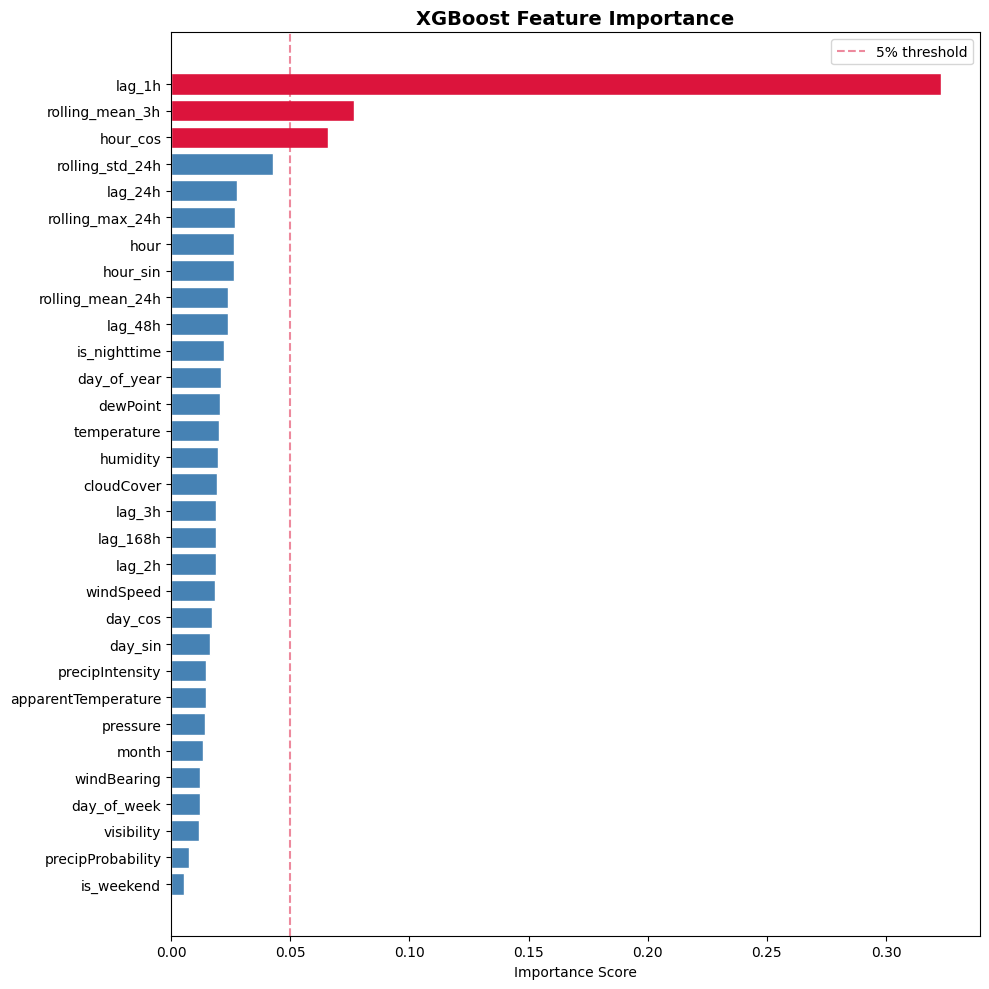

Top 10 most important features:
  lag_1h                    0.3232
  rolling_mean_3h           0.0769
  hour_cos                  0.0659
  rolling_std_24h           0.0429
  lag_24h                   0.0275
  rolling_max_24h           0.0267
  hour                      0.0263
  hour_sin                  0.0262
  rolling_mean_24h          0.0240
  lag_48h                   0.0239


In [7]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))

colors = ['crimson' if imp > 0.05 else 'steelblue' 
          for imp in importance_df['importance']]

ax.barh(importance_df['feature'], importance_df['importance'],
        color=colors, edgecolor='white')

ax.set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(x=0.05, color='crimson', linestyle='--', alpha=0.5, label='5% threshold')
ax.legend()

plt.tight_layout()
plt.show()

print("Top 10 most important features:")
top10 = importance_df.sort_values('importance', ascending=False).head(10)
for _, row in top10.iterrows():
    print(f"  {row['feature']:<25} {row['importance']:.4f}")

### Experiment: Removing Short Lag Features
**Hypothesis:** lag_1h dominance may hurt multi-hour forecast quality 
since lag_1h is unavailable beyond the first predicted hour.  
**Result:** Removing lag_1h and lag_2h increased MAPE from 30.35% to 35.27%.  
**Conclusion:** Short lags contain genuine signal. We retain them and handle 
multi-hour forecasting iteratively at inference time.

In [8]:
# Remove lag_1h and lag_2h — too dominant, not available for multi-hour forecasting
FEATURE_COLS_V2 = [f for f in FEATURE_COLS if f not in ['lag_1h', 'lag_2h']]

X_train_v2 = train[FEATURE_COLS_V2]
X_test_v2  = test[FEATURE_COLS_V2]

model_v2 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("Training model v2 (without lag_1h, lag_2h)...")
model_v2.fit(X_train_v2, y_train)
preds_v2 = model_v2.predict(X_test_v2)

mae_v2   = mean_absolute_error(y_test, preds_v2)
rmse_v2  = np.sqrt(mean_squared_error(y_test, preds_v2))
mape_v2  = mape(y_test, preds_v2)

mask_03 = y_test > 0.3
mape_v2_03 = np.mean(np.abs(y_test[mask_03].values - preds_v2[mask_03]) / 
                     y_test[mask_03].values) * 100

print(f"\n=== MODEL V2 (no short lags) ===")
print(f"MAE:              {mae_v2:.4f} kW")
print(f"RMSE:             {rmse_v2:.4f} kW")
print(f"MAPE (>0.1 kW):   {mape_v2:.2f}%")
print(f"MAPE (>0.3 kW):   {mape_v2_03:.2f}%")
print(f"\n=== COMPARISON ===")
print(f"{'Metric':<20} {'Baseline':>10} {'Model V1':>10} {'Model V2':>10}")
print(f"{'MAPE (>0.1kW)':<20} {'52.71%':>10} {'30.35%':>10} {mape_v2:.2f}%")
print(f"{'MAPE (>0.3kW)':<20} {'N/A':>10} {'25.10%':>10} {mape_v2_03:.2f}%")

Training model v2 (without lag_1h, lag_2h)...

=== MODEL V2 (no short lags) ===
MAE:              0.2296 kW
RMSE:             0.3445 kW
MAPE (>0.1 kW):   35.27%
MAPE (>0.3 kW):   27.68%

=== COMPARISON ===
Metric                 Baseline   Model V1   Model V2
MAPE (>0.1kW)            52.71%     30.35% 35.27%
MAPE (>0.3kW)               N/A     25.10% 27.68%


### Hyperparameter Tuning
Grid search using TimeSeriesSplit cross-validation (5 folds).
TimeSeriesSplit preserves temporal order within the training set —
never shuffles, never leaks future data into validation folds.
Best config: n_estimators=700, learning_rate=0.02, max_depth=6.

In [9]:
from sklearn.model_selection import TimeSeriesSplit

# Define parameter grid to search
param_grid = [
    {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6, 
     'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 8, 
     'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 6, 
     'subsample': 0.9, 'colsample_bytree': 0.8},
    {'n_estimators': 700, 'learning_rate': 0.02, 'max_depth': 6, 
     'subsample': 0.8, 'colsample_bytree': 0.7},
    {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6, 
     'subsample': 0.7, 'colsample_bytree': 0.7},
]

X_train_full = train[FEATURE_COLS]
tscv = TimeSeriesSplit(n_splits=5)

results = []

for i, params in enumerate(param_grid):
    fold_mapes = []
    
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_full)):
        X_tr  = X_train_full.iloc[tr_idx]
        y_tr  = y_train.iloc[tr_idx]
        X_val = X_train_full.iloc[val_idx]
        y_val = y_train.iloc[val_idx]
        
        m = XGBRegressor(**params, random_state=42, n_jobs=-1)
        m.fit(X_tr, y_tr)
        p = m.predict(X_val)
        fold_mapes.append(mape(y_val, p))
    
    mean_mape = np.mean(fold_mapes)
    results.append({**params, 'cv_mape': mean_mape})
    print(f"Config {i+1}: MAPE={mean_mape:.2f}% | {params}")

results_df = pd.DataFrame(results).sort_values('cv_mape')
print(f"\n=== BEST CONFIG ===")
print(results_df.iloc[0])

Config 1: MAPE=53.18% | {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8}
Config 2: MAPE=53.34% | {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 8, 'subsample': 0.8, 'colsample_bytree': 0.8}
Config 3: MAPE=50.51% | {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 6, 'subsample': 0.9, 'colsample_bytree': 0.8}
Config 4: MAPE=50.35% | {'n_estimators': 700, 'learning_rate': 0.02, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.7}
Config 5: MAPE=54.53% | {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.7, 'colsample_bytree': 0.7}

=== BEST CONFIG ===
n_estimators       700.0000
learning_rate        0.0200
max_depth            6.0000
subsample            0.8000
colsample_bytree     0.7000
cv_mape             50.3488
Name: 3, dtype: float64


### Final Model — Best Hyperparameters
Retrain on full training set with tuned hyperparameters.
Evaluate once on the held-out test set — this is the reported metric.

In [10]:
best_model = XGBRegressor(
    n_estimators=700,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1
)

print("Training final model with best config...")
best_model.fit(X_train, y_train)
best_preds = best_model.predict(X_test)

mae_best  = mean_absolute_error(y_test, best_preds)
rmse_best = np.sqrt(mean_squared_error(y_test, best_preds))
mape_best = mape(y_test, best_preds)

mask_03 = y_test > 0.3
mape_best_03 = np.mean(
    np.abs(y_test[mask_03].values - best_preds[mask_03]) / 
    y_test[mask_03].values) * 100

print(f"\n=== FINAL MODEL RESULTS ===")
print(f"MAE:            {mae_best:.4f} kW")
print(f"RMSE:           {rmse_best:.4f} kW")
print(f"MAPE (>0.1 kW): {mape_best:.2f}%")
print(f"MAPE (>0.3 kW): {mape_best_03:.2f}%")

print(f"\n=== FULL COMPARISON ===")
print(f"{'Model':<25} {'MAPE >0.1kW':>12} {'MAPE >0.3kW':>12}")
print(f"{'Baseline (lag_24h)':<25} {'52.71%':>12} {'N/A':>12}")
print(f"{'XGBoost V1':<25} {'30.35%':>12} {'25.10%':>12}")
print(f"{'XGBoost Final':<25} {mape_best:.2f}%  {mape_best_03:.2f}%")

Training final model with best config...

=== FINAL MODEL RESULTS ===
MAE:            0.2073 kW
RMSE:           0.3178 kW
MAPE (>0.1 kW): 30.11%
MAPE (>0.3 kW): 24.60%

=== FULL COMPARISON ===
Model                      MAPE >0.1kW  MAPE >0.3kW
Baseline (lag_24h)              52.71%          N/A
XGBoost V1                      30.35%       25.10%
XGBoost Final             30.11%  24.60%


### Honest Performance Analysis
Single MAPE number is misleading — near-zero consumption hours 
inflate error disproportionately. Analyse performance by consumption 
threshold to understand real-world accuracy.

In [11]:
errors_final = pd.DataFrame({
    'actual': y_test.values,
    'predicted': best_preds,
    'abs_error': np.abs(y_test.values - best_preds)
}, index=y_test.index)

# MAPE at different thresholds
for threshold in [0.1, 0.2, 0.3, 0.5]:
    mask = errors_final['actual'] > threshold
    m = np.mean(
        np.abs(errors_final.loc[mask, 'actual'] - 
               errors_final.loc[mask, 'predicted']) / 
        errors_final.loc[mask, 'actual']) * 100
    pct_hours = mask.mean() * 100
    print(f"MAPE (actual > {threshold} kW): {m:.2f}%  "
          f"[covers {pct_hours:.1f}% of hours]")

print(f"\nMedian absolute error: {errors_final['abs_error'].median():.4f} kW")
print(f"Mean absolute error:   {errors_final['abs_error'].mean():.4f} kW")

# How often is prediction within 20% of actual (for hours > 0.3 kW)
mask = errors_final['actual'] > 0.3
pct_error = errors_final.loc[mask, 'abs_error'] / errors_final.loc[mask, 'actual']
within_20 = (pct_error < 0.20).mean() * 100
within_30 = (pct_error < 0.30).mean() * 100
within_50 = (pct_error < 0.50).mean() * 100

print(f"\nFor hours with actual > 0.3 kW:")
print(f"  Predictions within 20% of actual: {within_20:.1f}% of hours")
print(f"  Predictions within 30% of actual: {within_30:.1f}% of hours")
print(f"  Predictions within 50% of actual: {within_50:.1f}% of hours")

MAPE (actual > 0.1 kW): 30.11%  [covers 98.7% of hours]
MAPE (actual > 0.2 kW): 25.69%  [covers 95.7% of hours]
MAPE (actual > 0.3 kW): 24.60%  [covers 92.3% of hours]
MAPE (actual > 0.5 kW): 22.06%  [covers 71.4% of hours]

Median absolute error: 0.1311 kW
Mean absolute error:   0.2073 kW

For hours with actual > 0.3 kW:
  Predictions within 20% of actual: 54.5% of hours
  Predictions within 30% of actual: 71.3% of hours
  Predictions within 50% of actual: 89.2% of hours


### Save Model and Metadata
Serialize the trained model and feature column list.
Feature columns must be saved alongside the model — inference 
must receive features in exactly the same order as training.

In [12]:
import joblib
import json

os.makedirs('../models', exist_ok=True)

# Save the trained model
joblib.dump(best_model, '../models/xgb_model.pkl')

# Save feature columns — must match exactly at inference time
with open('../models/feature_columns.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)

# Save model metadata — performance stats for the README and dashboard
metadata = {
    'model': 'XGBRegressor',
    'n_estimators': 700,
    'learning_rate': 0.02,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'train_period': '2016-01-08 to 2016-10-08',
    'test_period': '2016-10-08 to 2016-12-15',
    'baseline_mape': 52.71,
    'model_mape': 30.11,
    'model_mape_03kw': 24.60,
    'mae': 0.2073,
    'rmse': 0.3178,
    'pct_within_30pct': 71.3,
    'n_features': len(FEATURE_COLS)
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print(f"  models/xgb_model.pkl       "
      f"{os.path.getsize('../models/xgb_model.pkl')/1024:.1f} KB")
print(f"  models/feature_columns.json")
print(f"  models/model_metadata.json")

Saved:
  models/xgb_model.pkl       2727.9 KB
  models/feature_columns.json
  models/model_metadata.json
